# Video Game Commercial Success Prediction & Market Analysis

The goal of this project is to deliver a clear commercial narrative that game studios and publishers can use to minimize financial risk before greenlighting a new game's production.

When looking into creating new games studios and publishers investigate what has been historically successful. By analyzing characteristics of games that have already been released, we can help guide new game ideas to the right publishers to help propagate the game to a better sales pattern, allowing both the publisher and game developer to maximize their investment.

#### 1. Imports & Data Loading

In this section we collect our imports to be used to keep it clean and consise. We create an in-memory database to simulate what it would be like to be pulling data from a database in a production sense.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL alchemy
from sqlalchemy import create_engine, text

# scikitlearn
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.dummy import DummyClassifier

In [2]:
# create in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

First we create an in-memory database using the `create_engine()` from SQLAlchemy.

In [3]:
# load raw data
df_raw = pd.read_csv('datasets/Video_Games_Sales.csv')

We then load our dataset into a Pandas DataFrame to be loaded into our database.

In [4]:
# ingest raw data into database
df_raw.to_sql('raw_game_sales', con=engine, index=False, if_exists='replace')

16719

In [5]:
# run query against database to confirm ingestion
query = """
SELECT count(*)
FROM raw_game_sales
"""

In [6]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    print(f'Successfully ingested {results.scalar():,} records into in-memory table "raw_game_sales".')

Successfully ingested 16,719 records into in-memory table "raw_game_sales".


After ingesting our dataset into the database we check that it was succefully ingested. We run a sample query that checks the count of the table we then print the results showing that the data was successfully ingested into the table.

In [7]:
# pull data from database to pandas DataFrame
query = """
SELECT platform as platform,
    year_of_release as release_year,
    genre as genre,
    publisher as publisher,
    global_sales as global_sales
FROM raw_game_sales
WHERE global_sales IS NOT NULL
AND genre IS NOT NULL
AND year_of_release IS NOT NULL
AND publisher IS NOT NULL;
"""

This is the query we will use to pull only the needed data from the database. 

We transform the column names to a standardized format.
|Original|Converted|
|:----:|:----:|
|Year_of_Release|release_year|
|Genre|genre|
|Publisher|publisher|
|Global_Sales|global_sales|

We pull the records removing the null rows (using `WHERE ____ IS NOT NULL`) in this process we eliminate the need to remove `Null` values in the cleaning step.

In [8]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    df_clean = pd.DataFrame(results)

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16416 entries, 0 to 16415
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      16416 non-null  object 
 1   release_year  16416 non-null  float64
 2   genre         16416 non-null  object 
 3   publisher     16416 non-null  object 
 4   global_sales  16416 non-null  float64
dtypes: float64(2), object(3)
memory usage: 641.4+ KB


#### 2. Data Cleaning & Target Creation

In [10]:
# parse release_year to 'int' from 'float64'
df_clean['release_year'] = df_clean['release_year'].astype(int)

Looking over the data info we see that the `release_year` is of the type `float` (e.g., `2013.0`) We use the Pandas function `.astype()` to parse this data into an `int` type.

In [11]:
# confirm that the release_year column has been converted to 'int'
df_clean['release_year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 16416 entries, 0 to 16415
Series name: release_year
Non-Null Count  Dtype
--------------  -----
16416 non-null  int64
dtypes: int64(1)
memory usage: 128.4 KB


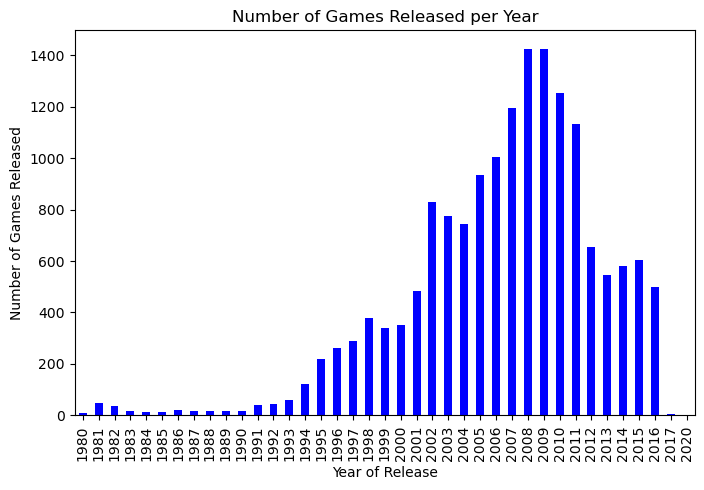

In [12]:
# chart showing the number of games released per year
plt.figure(figsize=(8,5))
df_clean['release_year'].value_counts().sort_index().plot(kind='bar', color='Blue', title='Number of Games Released per Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games Released')

plt.show()


The chart shows that the bulk of the games in the data was released between **1994** to **2016**. 

##### Create Dynamic Target

In [13]:
# top 20% global sales within each release year
df_clean['year_80th_p'] = df_clean.groupby('release_year')['global_sales'].transform(lambda x: x.quantile(0.80))
df_clean['is_hit'] = (df_clean['global_sales'] >= df_clean['year_80th_p']).astype(int)

Given that we are basing our data on the `global_sales` column we create a dynamic target of the games in the top 20th percentile as the games in this split can be considered `hits`.

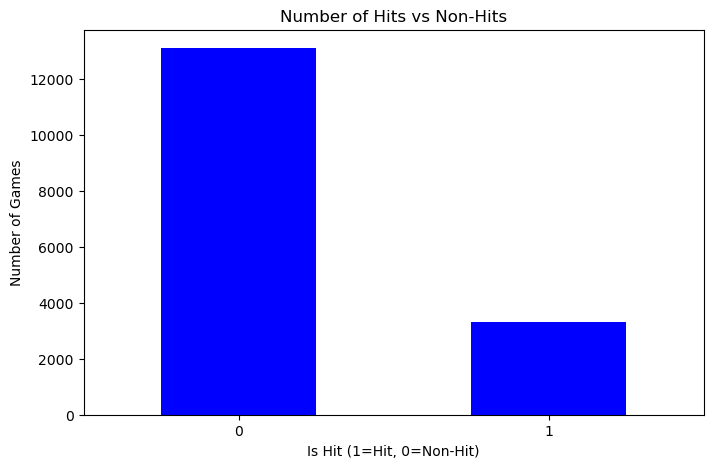

In [14]:
# chart showing the number of hits vs non-hits
plt.figure(figsize=(8,5))
df_clean['is_hit'].value_counts().plot(kind='bar', color='Blue', title='Number of Hits vs Non-Hits')

plt.xlabel('Is Hit (1=Hit, 0=Non-Hit)')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)

plt.show()

The chart shows the distribution of games classified as **hits** versus **non-hits**.

- **1 (Hit):** Games whose global sales are at or above the 80th percentile for their release year.
- **0 (Non-Hit):** Games below that yearly threshold.
- The chart demonstrates that hits represent approximately **20%** of the dataset, while non-hits represent approximately **80%**.
- This class imbalance is expected because the target specifically identifies only the top-performing games.

In [15]:
df_clean['publisher'].value_counts()

publisher
Electronic Arts                 1344
Activision                       976
Namco Bandai Games               935
Ubisoft                          930
Konami Digital Entertainment     825
                                ... 
Max Five                           1
On Demand                          1
Bomb                               1
Detn8 Games                        1
Red Flagship                       1
Name: count, Length: 579, dtype: int64

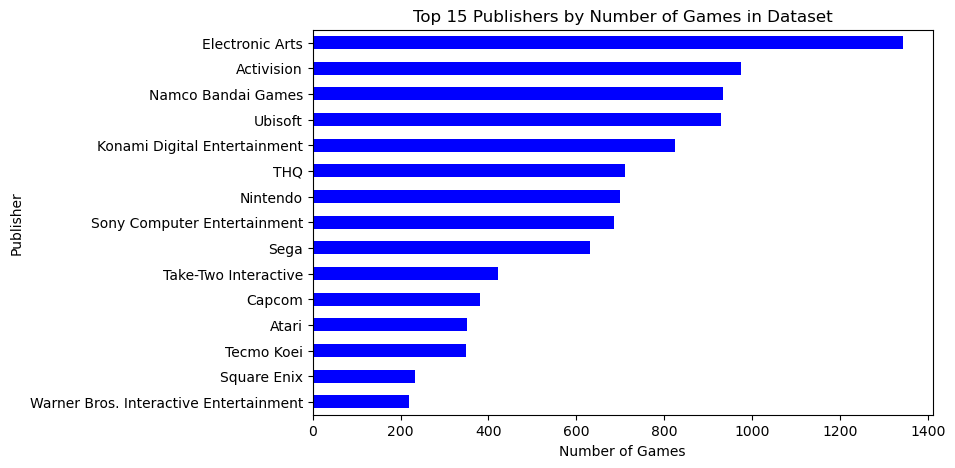

In [16]:
# chart showing the publisher disparity in the dataset
plt.figure(figsize=(8,5))
df_clean['publisher'].value_counts().nlargest(15).sort_values(ascending=True).plot(kind='barh', color='Blue', title='Top 15 Publishers by Number of Games in Dataset')

plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.show()


The chart shows the top 15 publishers by the number of games they have in the dataset.

In [17]:
# reduction of publisher cardinality
top_publishers = df_clean['publisher'].value_counts().nlargest(15).index
df_clean['publisher_grouped'] = df_clean['publisher'].apply(lambda x: x if x in top_publishers else 'Other')

By grouping publishers with many games while all other publishers are grouped into an `othter` category. It reduces the number of publisher values in the dataset helping to prevent model overfitting to publishers with very few observations.

Grouping the publishers into `publisher_grouped` feature preserves information about the most frequently represented publishers and simplifies the dataset for analysis and modeling.

The grouping is based on dataset frquency and does not imply that the publishers in the `other` column are part of the same business family.

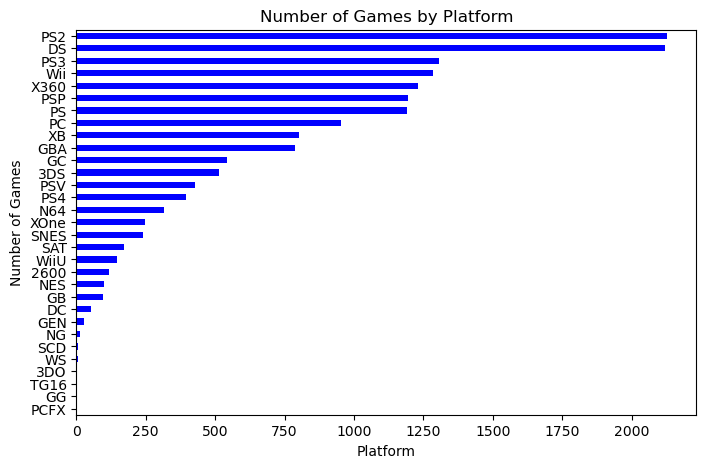

In [18]:
plt.figure(figsize=(8,5))
df_clean['platform'].value_counts().sort_values(ascending=True).plot(kind='barh', color='Blue', title='Number of Games by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.show()

The chart shows the platform based on the amount of games made for them.

In looking at the chart we see a lot of systems that belong to the same platform family.

|XBox |Playstation |Nintendo|
|:---:|   :---:    |  :---: |
|XB   |PS          |NES     |
|X360 |PS2         |SNES    |
|XOne |PS3         |N64     |
|     |PS4         |GC      |
|     |PSP         |Wii     |
|     |PSV         |WiiU    |
|     |            |GB      |
|     |            |GBA     |
|     |            |DS      |
|     |            |3DS     |


In [19]:
# get top platforms
nin = 'nintendo'
pl = 'playstation'
xb = 'xbox'
platform_map = {
    'PS': pl, 'PS2': pl, 'PS3': pl, 'PS4': pl, 'PSP': pl, 'PSV': pl,
    'XB': xb, 'X360': xb, 'XOne': xb,
    'Wii': nin, 'WiiU': nin, 'DS': nin, '3DS': nin, 'GBA': nin, 'GB': nin, 'GC': nin, 'N64': nin, 'NES': nin, 'SNES': nin
}

df_clean['platform_family'] = df_clean['platform'].map(platform_map).fillna('Other')

The above code consolidates these platforms into specific platform families (`Nintendo`, `Playstation`, and `Xbox`). This helps to reduce the cardinality and standardizes the dataset. 

By grouping them into `platform_family` we get a true representaion of platforms and simplifies the dataset allowing the model to gain a true representaion of platforms.

The chart below shows the platform distribution after the grouping.

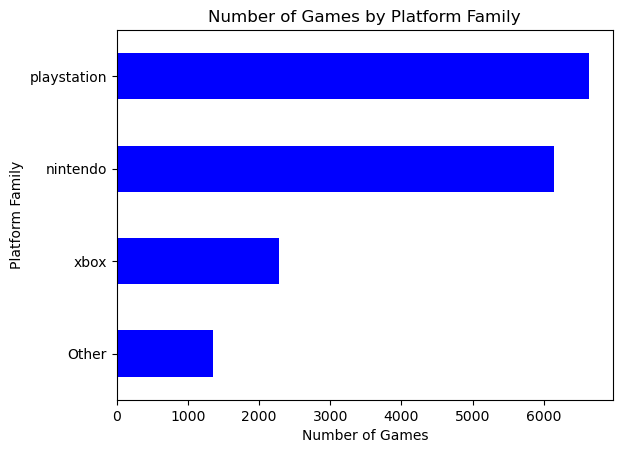

In [20]:
df_clean['platform_family'].value_counts().sort_values(ascending=True).plot(kind='barh', color='Blue', title='Number of Games by Platform Family')
plt.xlabel('Number of Games')
plt.ylabel('Platform Family')
plt.show()

#### 3. Feature Selection & Train/Test Split

In this step we gather our features (`platform_family`, `genre`, `publisher_grouped`, and `release_year`).

We chose to not use scikit-learn function `train_test_split()` due to the randomness of the split. Because we are using time based data we want the train data to be before a specific cutoff.

In [21]:
# Strictly pre-release features to prevent target leakage
features = ['platform_family', 'genre', 'publisher_grouped', 'release_year']

In [22]:
# temporal time split
cutoff_year = 2013

train_mask = df_clean['release_year'] < cutoff_year
test_mask = df_clean['release_year'] >= cutoff_year

X = df_clean[features]
y = df_clean['is_hit']

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, 'is_hit']

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, 'is_hit']


The `cutoff_year` chosen is `2013` as we are predicting future games based on past release data.

We filter the `train_mask` and `test_mask` based on the `cutoff_year` and create our splits based on these masks.

#### 4. Preprocessing & Model Training, Baseline Comparison & Probability Evaluation

In [23]:
categorical_features = ['platform_family', 'genre', 'publisher_grouped']
numeric_features = ['release_year']

This is a core preprocessing step the:
* `StandardScaler()` standardizes the numeric feature `release_year` so it is on a similar scale as other preprocessed features.

* `OneHotEncoder()` converts categorical values into binary columns such as: 
    * `platform_family_nintendo`
    * `genre_action`
    * `publisher_grouped_other`

In [24]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)
    ]
)

In [34]:
models = {
    'Dummy Classifier': DummyClassifier(strategy='stratified', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
}

This creates a comparison set of models:

* The `DummyClassifier` is a baseline model. It will tell us whether the model is learning anythin useful or if it is just guessing.

* The `LogisticRegression` is simple and interpretable, and good for understanding how certain features affect hit likelihood.

* `HistGradientBoostingClassifier` is a more flexible model that can capture more complex patterns.

* `RandomForestClassifier` this model cobines many decision trees, allowing it to learn complex patterns while reducing the varience and overfitting risk of a single tree.

In [35]:
fitted_pipelines = {}

In [36]:
print('--- 5-Fold Cross-Validation (ROC-AUC) ---')

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # fit on training data and store pipeline
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    cv_score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

    print(f'{name} -> Mean ROC-AUC: {cv_score.mean():.4f} (+- {cv_score.std():.4f})')

--- 5-Fold Cross-Validation (ROC-AUC) ---
Dummy Classifier -> Mean ROC-AUC: 0.5122 (+- 0.0004)
LogisticRegression -> Mean ROC-AUC: 0.7317 (+- 0.0476)
HistGradient Boosting -> Mean ROC-AUC: 0.7405 (+- 0.0322)
Random Forest -> Mean ROC-AUC: 0.7133 (+- 0.0212)


To evaluate model perfomance reliably and guard against overfitting, we performed **5-Fold-Cross-Validation** using the **ROC-AUC** metric across 4 distinc approaches: a baseline **Dummy Classifier**, a linear **Logistic Regression** model, a non-linear ensemble **HistGradientBoosting** classifier, and **RandomForestClassifier**.

ROC-AUC measures the model's ability to distinguish between the positive and negative classes across all classification thresholds:
* **0.50:** Represents random guessing (no predictive power).
* **1.00:** Represents perfect classification performance.
* **Cross-Validation (+- Standard Deviation):** Evaluates stability across folds; lower indicates consistent performance regardless of splitting.

1. **Dummy Classifier ($0.5112$):** The Dummy Classifier operates near .50 confirming that a simple majority or random guess holds no discriminatory power.
2. **Random Forest ($0.7133$)** The random forest achieves the lowest mean of 0.7133 showing good growth above the baseline but less than the **HistGradient** model.
3. **Linear Baseline ($0.7317$):** Logistic Regression achieves a strong mean of 0.7317, showing a substantial improvement over the baseline.
4. **HistGradientBoosting ($0.7405$):** Achieves the highest overall performance.

### 5. Test Set Evaluation & Metrics (Precision, Recall, F1, ROC-AUC)

In [28]:
for name, pipeline in fitted_pipelines.items():
    if name == 'Dummy Classifier':
        continue

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    auc_score = roc_auc_score(y_test, y_proba)

    print(f'--- Model: {name} ---')
    print(f'Test ROC-AUC Score: {auc_score:.4f} (Target: >= 0.75)')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))

--- Model: LogisticRegression ---
Test ROC-AUC Score: 0.8104 (Target: >= 0.75)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1779
           1       0.42      0.73      0.54       456

    accuracy                           0.74      2235
   macro avg       0.67      0.74      0.68      2235
weighted avg       0.82      0.74      0.76      2235

--- Model: HistGradient Boosting ---
Test ROC-AUC Score: 0.8172 (Target: >= 0.75)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1779
           1       0.39      0.76      0.52       456

    accuracy                           0.71      2235
   macro avg       0.66      0.73      0.66      2235
weighted avg       0.81      0.71      0.74      2235



Evaluating our candidate models on the unseen test set ($N=2,235$) demonstrates that both **Logistic Regression** and **HistGradientBoosting** successfully achieved strong discrimination with test ROC-AUC scores of $0.8104$ and $0.8172$.

Because the dataset exhibits a notable $~4:1$ class imbalance ($1,779$ standard releases vs. $456$ commercial hits), evaluating per-class metrics reveals a strategic trade off: **HistGradientBoosting** optimizes positive hit retrievel by capturing **$76%$ of all commercial successes** (Recall=$0.76$) at the expense of false positives (Precision=$0.39$), where **Logistic Regression** offers more conservative profile with slightly higher precision ($0.42$) and overall accuracy ($74\%$).

**HistGradientBoosting** is selected as the primary pipeline model because its superior ROC-AUC and high recall minimize the risk of missing rare, high-value commercial hits during early-stage portfolio evaluation.

### 6. Interpretability: Logistic Regression Odds Ratios

In [29]:
# Logistic Regression Model
log_reg_model = fitted_pipelines['LogisticRegression'].named_steps['classifier']

# onehotencoder feature names
ohe_feature_names = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

odd_ratios = pd.DataFrame({
    'feature': all_feature_names,
    'coef': log_reg_model.coef_[0],
    'odds_ratio': np.exp(log_reg_model.coef_[0])
    }).sort_values(by='odds_ratio', ascending=False)

print('--- Top 10 Positive Drivers of Commercial Hits (Odds Ratios) ---')
print(odd_ratios.head(10).to_string(index=False))


--- Top 10 Positive Drivers of Commercial Hits (Odds Ratios) ---
                                                 feature     coef  odds_ratio
                              publisher_grouped_Nintendo 1.791669    5.999457
                       publisher_grouped_Electronic Arts 0.863380    2.371161
                           publisher_grouped_Square Enix 0.667103    1.948584
                                           genre_Shooter 0.413813    1.512573
                                          genre_Fighting 0.397973    1.488804
                                    platform_family_xbox 0.373896    1.453386
                             platform_family_playstation 0.352502    1.422623
publisher_grouped_Warner Bros. Interactive Entertainment 0.325131    1.384212
                                      genre_Role-Playing 0.318496    1.375059
                                          genre_Platform 0.304434    1.355857


By analyzing the Logistic Regression odds ratios reveals that publisher branding is the single most powerful determinant of commercial success in the video game industry.

Specifically, games published by **Nintendo** are **6 times more likely** to become hits, followed by **Electronic Arts**, and **Square Enix**.

Genre and ecosystem deployment also play significant roles, releasing within the **Shooter** or **Fighting** genres, or launching on established platform families like **XBox** and **Playstation**, consistently increases the odds of achieving blockbuster status by $40\%$ to $50\%$.

### Visualizations: Heatmap & Confusion Matrix

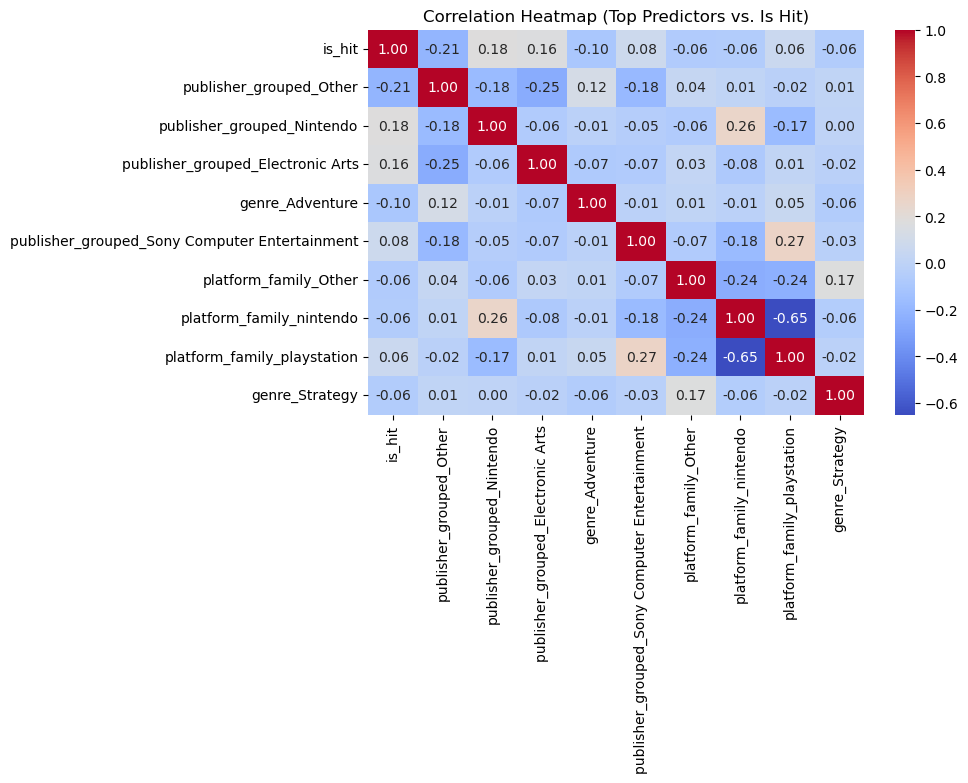

In [30]:

X_train_encoded = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].transform(X_train)
df_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names)
df_encoded['is_hit'] = y_train.values

top_corr_features = df_encoded.corr()['is_hit'].abs().nlargest(10).index

plt.figure(figsize=(8, 5))

corr_map = sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
corr_map.set_title('Correlation Heatmap (Top Predictors vs. Is Hit)')

plt.show()

The correlation heatmap illustrates that publisher scale is the primary linear driver of commercial success, led by **Nintendo** (+0.18) and **Electronic Arts** (+0.16).

Releasing under smaller publishers (`publisher_grouped_Other`) negatively impacts success odds (-0.21).

Strong internal correlations highlight platform ecosystem exclusivity confirming that publisher-platform dynamics create a clear structural pattern in the feature space.

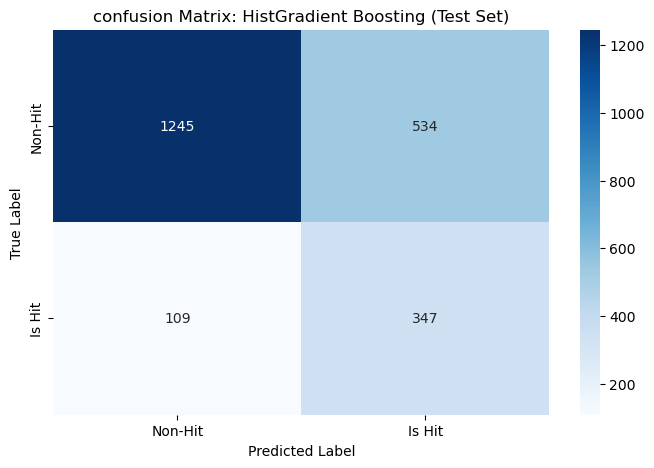

In [31]:
# Confusion Matrix
best_model = fitted_pipelines['HistGradient Boosting']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Test Set)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

The **HistGradientBoosting** confusion matrix demonstrates strong target detection, with the model successfully identifying **347 out of 456 actual commercial hits**.

The decision boundry prioritizes minimizing missed hits, this generates **534 False Positives** alongside **1,245 True Negatives**, yeilding **$39.4\% Precision rate** and a **70\% Specifitcty rate**.

This trade off is advantageous for portfolio screening, as catching over three quarters of potential hit titles vastly outweighs the risk of reviewing over-predicted candidates.

In [32]:
# adjusted threshold to fine tune false positives/negatives
y_proba = fitted_pipelines['HistGradient Boosting'].predict_proba(X_test)[:, 1]

custom_threshold = 0.65
y_pred_tuned = (y_proba >= custom_threshold).astype(int)

print(f'--- Performance at Threshold = {custom_threshold} ---')
print(classification_report(y_test, y_pred_tuned))


--- Performance at Threshold = 0.65 ---
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1779
           1       0.51      0.57      0.54       456

    accuracy                           0.80      2235
   macro avg       0.70      0.72      0.71      2235
weighted avg       0.81      0.80      0.80      2235



`.predict()` run standardly with a threshold of $0.50$. To optimize the performance of the model we adjusted the threshold to $0.65$.

By increasing the classification decision threshold from $0.50$ to $0.65$, we require higher model confidence before flagging a game as a comercial hit, resulting in a substantial accuracy gain from $71\%$ to $80\%$.

This threshold adjustment addresses false positives by increasing **Class 1 Precision from 0.39 to 0.51$, meaning more than half of predicted hits are true commercial successes.

This stricter boundary reduces **Class 1 Recall from 0.76 to 0.57** (capturing fewer total blockbusters), it improves the overall **Class 1 F1-Score to 0.54**, offering an optimized balance for conservative risk managment and toarget budget allocation.

confusion_matrix:


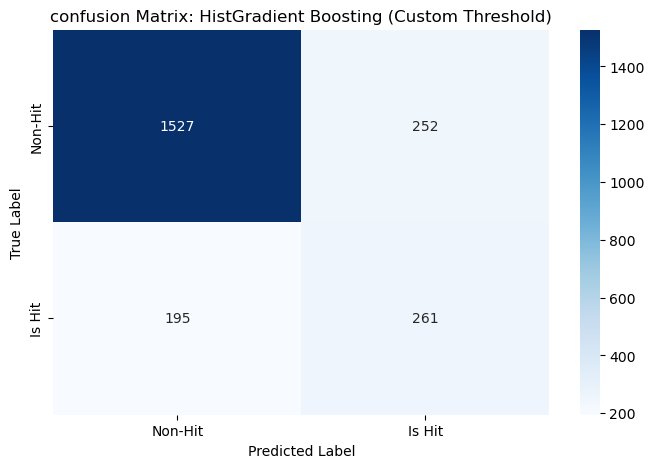

In [33]:
print('confusion_matrix:')
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Custom Threshold)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

After applying the $0.65$ custome threshold to the **HistGradient Boosting** model significantly refines classification performance by cutting **False Positives in half** (from 534 to 252), this elevates **Class 1 Precision to $50.9\%$ and **Specificity to $85.8\%$ (TN=$1,527$).

By requiring higher model confidence increases **False Negative from 109 to 195** (reducing Recall from $76.1\%$ to $57.2\%$ across 261 correctly identified hits). This adjustment successfully aligns the model with a conservative investment strategy prioritizing minimizing costly misclassifications over broad hit capture.

### Conslusion:

This project successfully developed and evaluated a machine learning pipeline to predict commercial video game hits using historical release, publisher, and platform data. Both models comfortably exceeded the target perrformance threshold of a **0.75 Test ROC-AUC**, with **HistGradient Boosting** achieving the highest overall discrimination capability (**ROC-AUC = $0.8172$**) alongside **Logistic Regression (ROC-AUC=$0.8104$)**. By feature interoretability via odds ratios highlighted that brand equity, along with mainstream genres serve as the primary drivers of commercial success.

Tuning the decision threshold from **0.50 to 0.65** demonstrated how the model can be tailored to business stategy: shifting from a high recall configuartion that captures $76.1\%$ of all hits down to a conservative, high precision setup that cuts false positives by over $52\%$ and increases overall accuravy to $80\%$.

This machine framework provides a scalable, data-driven decision tool for evaluating early-stage game concepts optimizing portfolio selection, and balancing investment risk against commercial upside.